In [158]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from pathlib import Path
_src = str(Path(globals()['__vsc_ipynb_file__']).parents[2] / 'src')
if _src not in sys.path:
    sys.path.insert(0, _src)

In [159]:
from utils.plot_config import set_korean_font

warnings.filterwarnings('ignore')
# sns.set_theme() 이 rcParams 를 초기화하므로 먼저 호출한 뒤 set_korean_font() 를 적용
sns.set_theme(style='white', palette='muted')
set_korean_font()

COLORS = {0: '#1f77b4', 1: '#ff7f0e'}

[PLOT_CONFIG] OS='Darwin' → 'AppleGothic' font will be used for Korean text.


## 1. 데이터 로드


In [160]:
df = pd.read_csv('../../data/processed/ljh_preprocessed.csv')
df.head()

,user_id,country_id,gender,age_group,reg_date,first_deposit,first_bet,fixed_bet_amount,live_bet_amount,total_bet_amount,...,fixed_hit_days,live_hit_days,total_hit_days,fixed_win_rate,live_win_rate,total_win_rate,fixed_avg_roi,live_avg_roi,total_avg_roi,churn
0,1324354,276.0,1.0,3.0,2005-02-01,2005-02-24,2005-02-24,15750.38,2146.47,17896.85,...,93.0,22.0,29.0,0.24,0.42,0.27,-0.00,-0.09,-0.08,0
1,1324355,300.0,1.0,1.0,2005-02-01,2005-02-01,2005-02-01,639.30,24.70,664.00,...,15.0,1.0,1.0,0.14,0.14,0.20,0.17,-0.76,-0.77,0
2,1324356,276.0,1.0,2.0,2005-02-01,2005-02-01,2005-02-02,898.81,701.82,1600.63,...,12.0,18.0,18.0,0.12,0.26,0.33,0.38,-0.25,0.64,0
3,1324358,752.0,1.0,1.0,2005-02-01,2005-02-01,2005-02-01,247.70,88.59,336.29,...,1.0,1.0,1.0,0.00,0.00,0.00,-0.88,-0.37,-0.54,1
4,1324360,792.0,1.0,2.0,2005-02-01,2005-02-02,2005-02-02,685.94,6.66,692.61,...,14.0,2.0,3.0,0.14,0.25,0.50,0.89,-0.63,6.99,0


In [161]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 46339 entries, 0 to 46338
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            46339 non-null  int64  
 1   country_id         46337 non-null  float64
 2   gender             46337 non-null  float64
 3   age_group          46337 non-null  float64
 4   reg_date           46337 non-null  str    
 5   first_deposit      46337 non-null  str    
 6   first_bet          46337 non-null  str    
 7   fixed_bet_amount   46337 non-null  float64
 8   live_bet_amount    46337 non-null  float64
 9   total_bet_amount   46337 non-null  float64
 10  fixed_win_amount   46337 non-null  float64
 11  live_win_amount    46337 non-null  float64
 12  total_win_amount   46337 non-null  float64
 13  fixed_bet_cnt      46337 non-null  float64
 14  live_bet_cnt       46337 non-null  float64
 15  total_bet_cnt      46337 non-null  float64
 16  fixed_active_days  46337 non-null

In [162]:
df.describe()

,user_id,country_id,gender,age_group,fixed_bet_amount,live_bet_amount,total_bet_amount,fixed_win_amount,live_win_amount,total_win_amount,...,fixed_hit_days,live_hit_days,total_hit_days,fixed_win_rate,live_win_rate,total_win_rate,fixed_avg_roi,live_avg_roi,total_avg_roi,churn
count,4.633900e+04,46337.000000,46337.000000,46337.00000,46337.000000,46337.000000,46337.000000,46337.00000,46337.000000,46337.000000,...,45609.000000,31402.000000,28164.000000,45609.000000,31402.000000,28164.000000,45609.000000,31402.000000,28164.000000,46339.000000
mean,1.365008e+06,362.231457,0.919093,1.97065,1192.921425,1577.878537,2770.799993,1038.62267,1473.088319,2511.710982,...,15.893639,15.869626,13.879172,0.178540,0.330293,0.301053,-0.267395,-0.261136,0.320296,0.280908
std,2.322630e+04,193.114762,0.272696,1.02184,5124.679464,13279.839039,15987.791697,4795.08205,12660.658539,15088.095514,...,31.276931,38.372436,31.062806,0.152304,0.261951,0.262280,20.896053,0.674325,37.529711,0.449448
min,1.324354e+06,8.000000,0.000000,0.00000,0.000000,0.000000,0.040000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,0.000000
25%,1.345069e+06,276.000000,1.000000,1.00000,68.300000,0.000000,98.790000,26.72000,0.000000,49.430000,...,1.000000,1.000000,1.000000,0.040000,0.120000,0.000000,-0.810000,-0.560000,-0.460000,0.000000
50%,1.365092e+06,276.000000,1.000000,2.00000,216.680000,20.000000,305.440000,152.36000,10.400000,227.710000,...,5.000000,4.000000,4.000000,0.170000,0.330000,0.300000,-0.450000,-0.250000,-0.160000,0.000000
75%,1.385062e+06,300.000000,1.000000,3.00000,699.410000,175.820000,1040.010000,574.41000,145.290000,883.730000,...,17.000000,13.000000,12.000000,0.270000,0.500000,0.450000,-0.160000,-0.050000,0.090000,1.000000
max,1.405190e+06,891.000000,1.000000,8.00000,380093.970000,746243.350000,843123.650000,420949.25000,723318.790000,812114.250000,...,543.000000,546.000000,525.000000,1.000000,1.000000,1.000000,4455.210000,44.230000,6204.080000,1.000000


## 2. 결측치 처리

| 컬럼                              | 결측 원인                         | 처리 방침       |
| --------------------------------- | --------------------------------- | --------------- |
| `fixed_hit_days`, `live_hit_days` | 해당 유형 베팅 이력 없음          | **0** 으로 채움 |
| `fixed_win_rate`, `fixed_avg_roi` | Fixed 베팅 0회 → 분모 0 (730명)   | **NaN 유지**    |
| `live_win_rate`, `live_avg_roi`   | Live 베팅 0회 → 분모 0 (14,937명) | **NaN 유지**    |


In [163]:
df.isnull().sum()

user_id                  0
country_id               2
gender                   2
age_group                2
reg_date                 2
first_deposit            2
first_bet                2
fixed_bet_amount         2
live_bet_amount          2
total_bet_amount         2
fixed_win_amount         2
live_win_amount          2
total_win_amount         2
fixed_bet_cnt            2
live_bet_cnt             2
total_bet_cnt            2
fixed_active_days        2
live_active_days         2
total_active_days        2
fixed_hit_days         730
live_hit_days        14937
total_hit_days       18175
fixed_win_rate         730
live_win_rate        14937
total_win_rate       18175
fixed_avg_roi          730
live_avg_roi         14937
total_avg_roi        18175
churn                    0
dtype: int64

### 2-1. hit_days 결측값 처리

`fixed_hit_days`, `live_hit_days` 결측 → 해당 유형 베팅 이력이 없는 유저이므로 0으로 처리


In [164]:

df[['fixed_hit_days', 'live_hit_days']] = (
    df[['fixed_hit_days', 'live_hit_days']].fillna(0).astype(int)
)
df[['fixed_hit_days', 'live_hit_days']].dtypes

fixed_hit_days    int64
live_hit_days     int64
dtype: object

### 2-2. win_rate / avg_roi 결측값 처리

`fixed_win_rate`, `fixed_avg_roi` : Fixed 베팅 이력이 없는 **730명** → 분모(`BetsF > 0` 수)가 0이므로 정의 불가

`live_win_rate`, `live_avg_roi` : Live 베팅 이력이 없는 **14,937명** (전체 약 32%) → 동일 이유로 NaN.


In [165]:
assert (df[df['fixed_win_rate'].isnull()]['fixed_bet_cnt'] == 0).all()
assert (df[df['live_win_rate'].isnull()]['live_bet_cnt'].isna() | (df[df['live_win_rate'].isnull()]['live_bet_cnt'] == 0)).all()

print(df[['fixed_win_rate','live_win_rate','fixed_avg_roi','live_avg_roi']].isnull().sum().to_string())

fixed_win_rate      730
live_win_rate     14937
fixed_avg_roi       730
live_avg_roi      14937


In [166]:
# EDA 전용 복사본 — win_rate/avg_roi NaN 을 0 으로 채운 버전 (시각화용)
df_eda = df.copy()
df_eda['has_fixed'] = (df_eda['fixed_bet_cnt'] > 0).astype(int)
df_eda['has_live']  = (df_eda['live_bet_cnt']  > 0).astype(int)
for col in ['fixed_win_rate', 'live_win_rate', 'fixed_avg_roi', 'live_avg_roi']:
    df_eda[col] = df_eda[col].fillna(0)

# PSY 방식 total_win_rate 재계산:
# (fixed_win_rate * DaysF + live_win_rate * DaysL) / DaysA
# Fixed·Live 겹치는 날이 있으면 DaysF+DaysL > DaysA → 200%까지 나올 수 있음
df_eda['total_win_rate'] = (
    (df_eda['fixed_win_rate'] * df_eda['fixed_active_days']) +
    (df_eda['live_win_rate']  * df_eda['live_active_days'])
) / df_eda['total_active_days'].replace(0, np.nan)
df_eda['total_win_rate'] = df_eda['total_win_rate'].fillna(0).round(2)

print(f'df_eda shape : {df_eda.shape}')
print(f'has_fixed=1  : {df_eda["has_fixed"].sum():,}명')
print(f'has_live=1   : {df_eda["has_live"].sum():,}명')
print(f'total_win_rate max : {df_eda["total_win_rate"].max():.2f}  '
      f'(100% 초과 유저: {(df_eda["total_win_rate"] > 1.0).sum():,}명)')

df_eda shape : (46339, 31)
has_fixed=1  : 45,601명
has_live=1   : 31,378명
total_win_rate max : 2.00  (100% 초과 유저: 41명)


## 3. 타겟 변수 (Churn) 분포

- 기준일(2006-08-31)로부터 마지막 베팅일까지 **395일(≈13개월) 초과**하면 이탈(churn=1).


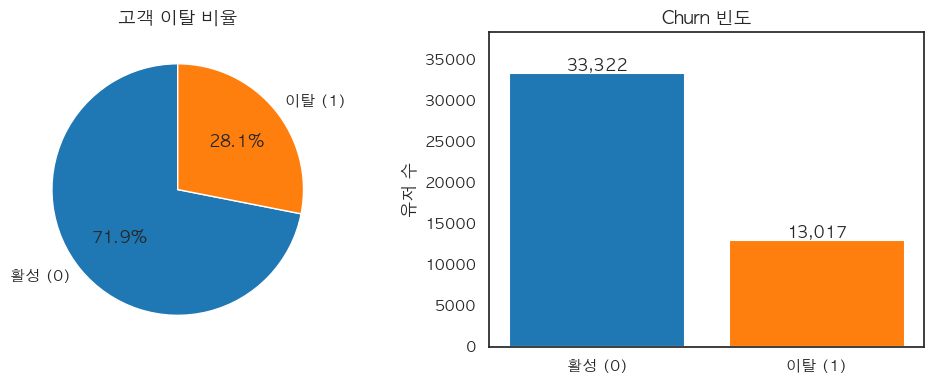

In [167]:
churn_cnt = df['churn'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 파이 차트
axes[0].pie(
  churn_cnt,
  labels=['활성 (0)', '이탈 (1)'],
  colors=[COLORS[0], COLORS[1]],
  startangle=90,
  autopct='%1.1f%%',
  wedgeprops={'edgecolor': 'white'}
)
axes[0].set_title('고객 이탈 비율', fontsize=13)

bars = axes[1].bar(
    ['활성 (0)', '이탈 (1)'], churn_cnt.values,
    color=[COLORS[0], COLORS[1]], edgecolor='white', linewidth=1.5
)
axes[1].set_title('Churn 빈도', fontsize=13)
axes[1].set_ylabel('유저 수')
axes[1].set_ylim(0, churn_cnt.max() * 1.15)
for bar, v in zip(bars, churn_cnt.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
                 f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. 범주형 변수 탐색

`gender`, `age_group`, `country_id`


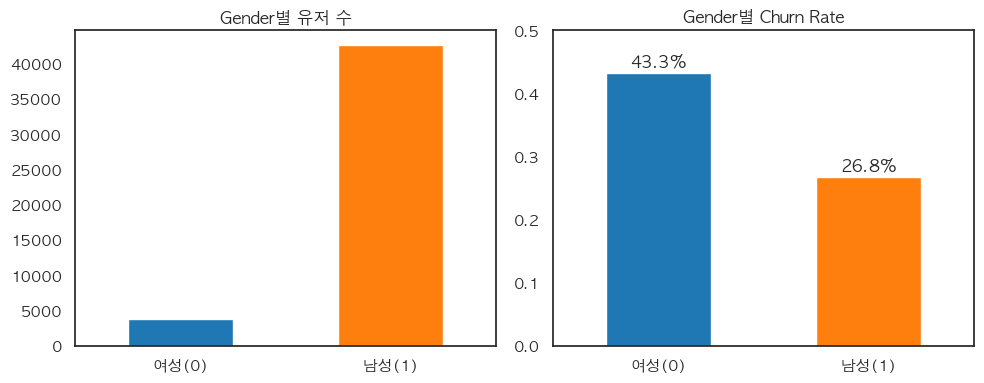

       count  churn_sum  churn_rate
여성(0)   3749       1622    0.432649
남성(1)  42588      11394    0.267540


In [168]:
AGE_LABELS = {-1:'미상',0:'10대',1:'20대',2:'30대',3:'40대',
              4:'50대',5:'60대',6:'70대',7:'80대',8:'90대+'}

# 4-1 Gender
gender_churn = (
    df.groupby('gender')['churn']
    .agg(count='count', churn_sum='sum')
    .assign(churn_rate=lambda x: x['churn_sum']/x['count'])
)
gender_churn.index = ['여성(0)','남성(1)']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
gender_churn['count'].plot(kind='bar', ax=axes[0],
    color=[COLORS[0], COLORS[1]], edgecolor='white')
axes[0].set_title('Gender별 유저 수', fontsize=12)
axes[0].tick_params(axis='x', rotation=0)

gender_churn['churn_rate'].plot(kind='bar', ax=axes[1],
    color=[COLORS[0], COLORS[1]], edgecolor='white')
axes[1].set_title('Gender별 Churn Rate', fontsize=12)
axes[1].set_ylim(0, 0.5); axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(gender_churn['churn_rate']):
    axes[1].text(i, v+0.01, f'{v:.1%}', ha='center', fontweight='bold')
plt.tight_layout(); plt.show()
print(gender_churn)

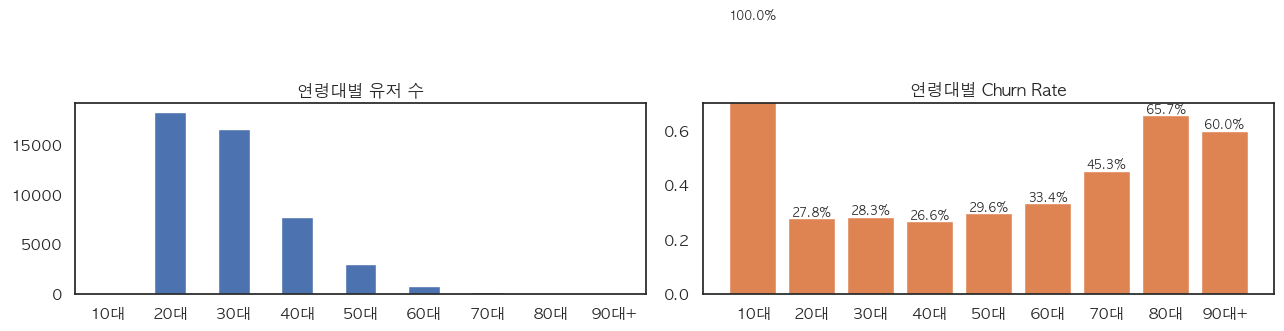

In [169]:
# 4-2 Age Group
age_churn = (
    df.groupby('age_group')['churn']
    .agg(count='count', churn_sum='sum')
    .assign(churn_rate=lambda x: x['churn_sum']/x['count'])
)
age_churn.index = [AGE_LABELS.get(i, str(i)) for i in age_churn.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
age_churn['count'].plot(kind='bar', ax=axes[0], color='#4C72B0', edgecolor='white')
axes[0].set_title('연령대별 유저 수', fontsize=12)
axes[0].tick_params(axis='x', rotation=0)

bars = axes[1].bar(range(len(age_churn)), age_churn['churn_rate'],
                   color='#DD8452', edgecolor='white')
axes[1].set_xticks(range(len(age_churn))); axes[1].set_xticklabels(age_churn.index)
axes[1].set_title('연령대별 Churn Rate', fontsize=12); axes[1].set_ylim(0, 0.7)
for bar, v in zip(bars, age_churn['churn_rate']):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.1%}', ha='center', fontsize=8.5)
plt.tight_layout(); plt.show()

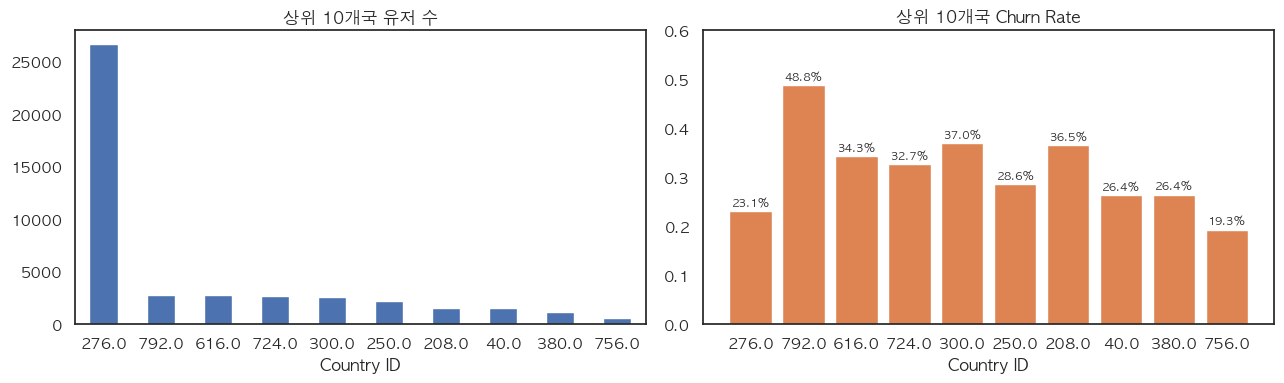

In [170]:
# 4-3 Country (상위 10개국)
top10 = df['country_id'].value_counts().head(10).index
country_churn = (
    df[df['country_id'].isin(top10)]
    .groupby('country_id')['churn']
    .agg(count='count', churn_sum='sum')
    .assign(churn_rate=lambda x: x['churn_sum']/x['count'])
    .sort_values('count', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
country_churn['count'].plot(kind='bar', ax=axes[0], color='#4C72B0', edgecolor='white')
axes[0].set_title('상위 10개국 유저 수', fontsize=12)
axes[0].set_xlabel('Country ID'); axes[0].tick_params(axis='x', rotation=0)

bars = axes[1].bar(range(len(country_churn)), country_churn['churn_rate'],
                   color='#DD8452', edgecolor='white')
axes[1].set_xticks(range(len(country_churn))); axes[1].set_xticklabels(country_churn.index)
axes[1].set_title('상위 10개국 Churn Rate', fontsize=12)
axes[1].set_ylim(0, 0.6); axes[1].set_xlabel('Country ID')
for bar, v in zip(bars, country_churn['churn_rate']):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.1%}', ha='center', fontsize=8)
plt.tight_layout(); plt.show()

## 5. 상관관계 히트맵

수치형 변수 간 Pearson 상관계수를 히트맵으로 표시.


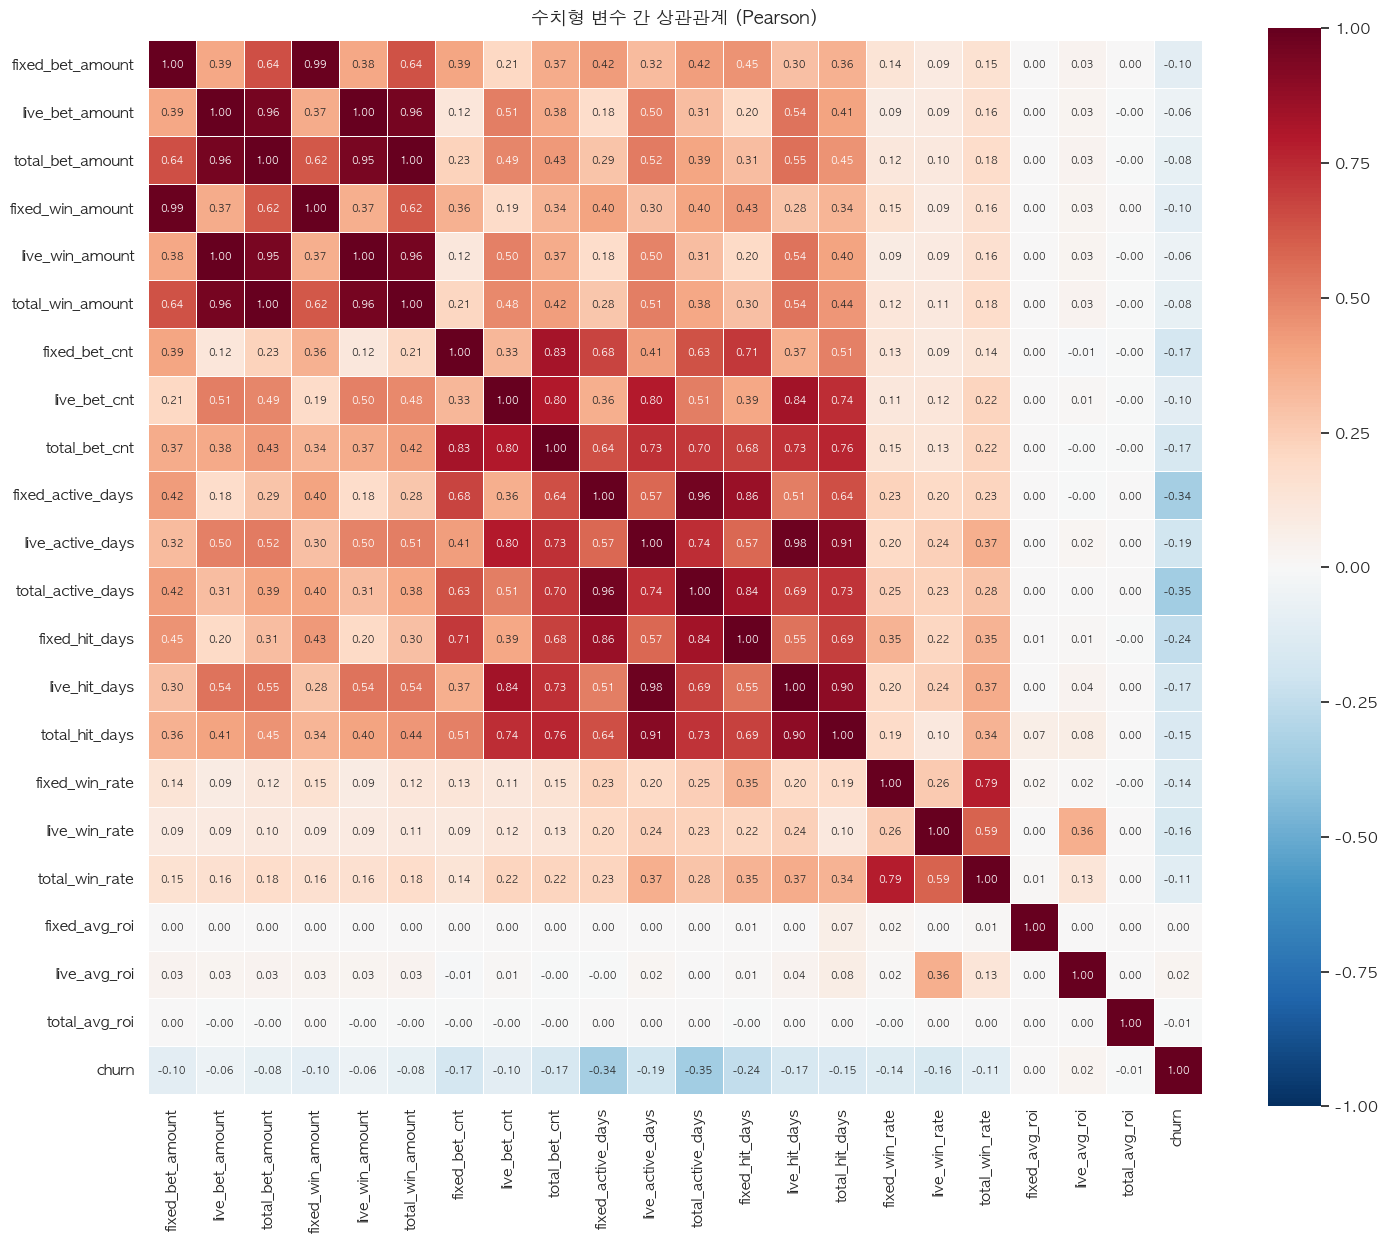

In [171]:
feat_cols = [
    'fixed_bet_amount','live_bet_amount','total_bet_amount',
    'fixed_win_amount','live_win_amount','total_win_amount',
    'fixed_bet_cnt','live_bet_cnt','total_bet_cnt',
    'fixed_active_days','live_active_days','total_active_days',
    'fixed_hit_days','live_hit_days','total_hit_days',
    'fixed_win_rate','live_win_rate','total_win_rate',
    'fixed_avg_roi','live_avg_roi','total_avg_roi',
    'churn',
]
corr = df_eda[feat_cols].corr()

fig, ax = plt.subplots(figsize=(17, 14))
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.4, annot_kws={'size':7}, ax=ax)
ax.set_title('수치형 변수 간 상관관계 (Pearson)', fontsize=13, pad=12)
plt.show()

## 6. Churn별 주요 지표 Boxplot

### 6-1. 전체 유저


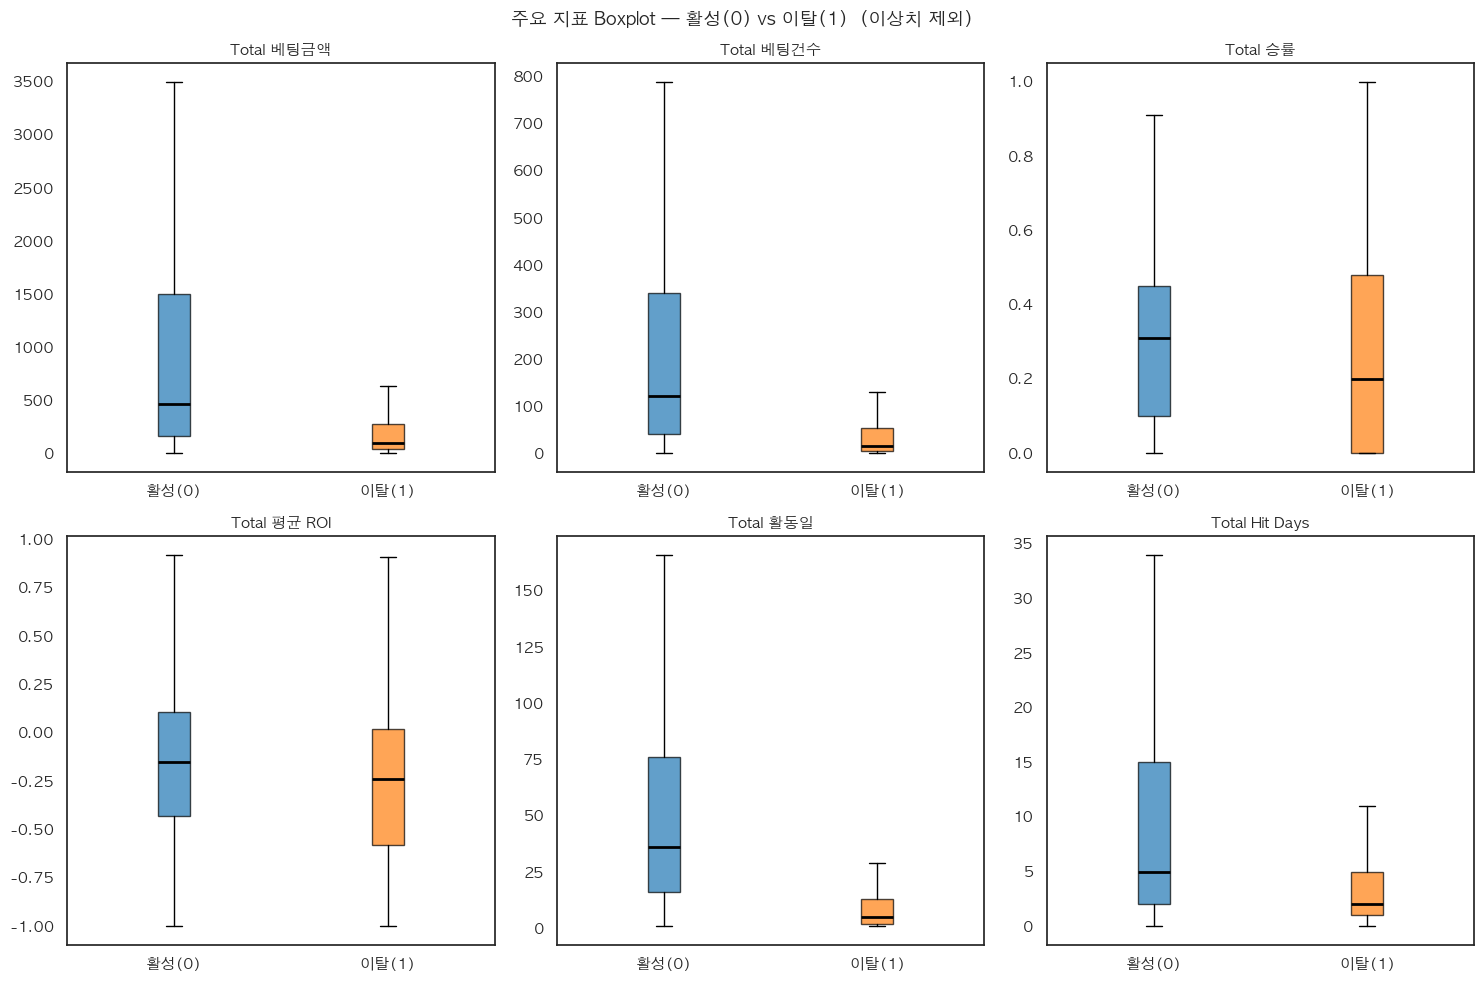

In [172]:
features = ['total_bet_amount','total_bet_cnt','total_win_rate',
            'total_avg_roi','total_active_days','total_hit_days']
titles   = ['Total 베팅금액','Total 베팅건수','Total 승률',
            'Total 평균 ROI','Total 활동일','Total Hit Days']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('주요 지표 Boxplot — 활성(0) vs 이탈(1)  (이상치 제외)', fontsize=13)
for ax, col, title in zip(axes.flatten(), features, titles):
    data = [df[df['churn']==cv][col].dropna().values for cv in [0,1]]
    bp = ax.boxplot(data, labels=['활성(0)','이탈(1)'],
                    patch_artist=True, showfliers=False,
                    medianprops={'color':'black','linewidth':2})
    for patch, cv in zip(bp['boxes'],[0,1]):
        patch.set_facecolor(COLORS[cv]); patch.set_alpha(0.7)
    ax.set_title(title, fontsize=11)
plt.tight_layout(); plt.show()

### 6-2.유저 충성도 (total_active_days ≥ 3) ㄴㄴ


전체 유저          : 46,339
3일+ 활동 유저     : 41,772  (90.1%)
진지한 유저 Churn  : 22.2%  (전체: 28.1%)


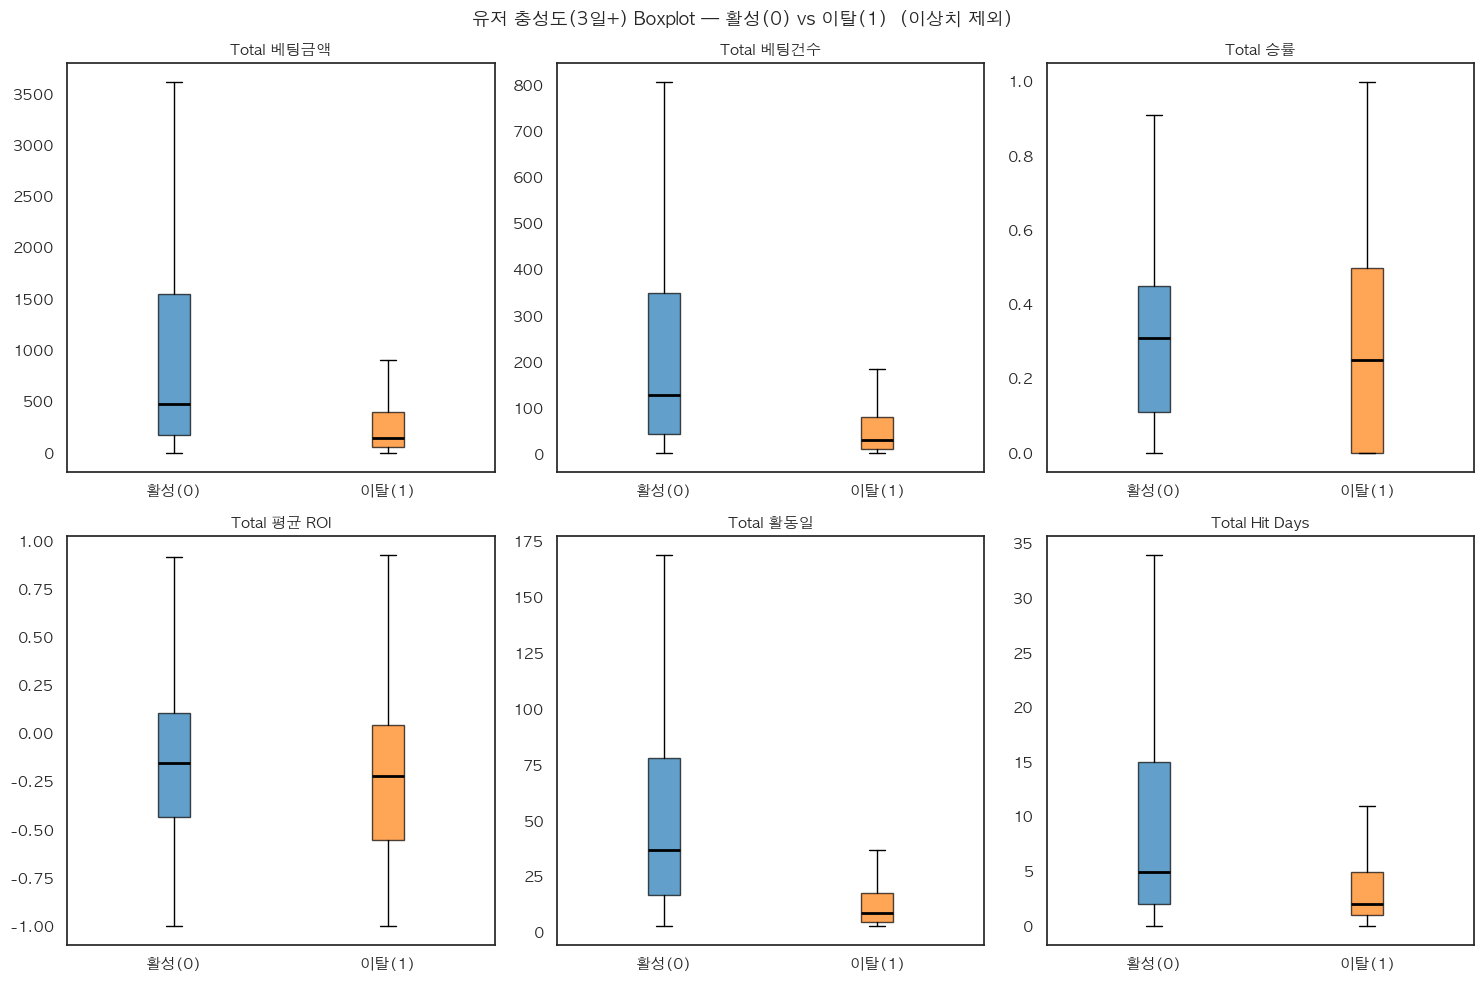

In [173]:
engaged = df[df['total_active_days'] >= 3].copy()
print(f'전체 유저          : {len(df):,}')
print(f'3일+ 활동 유저     : {len(engaged):,}  ({len(engaged)/len(df)*100:.1f}%)')
print(f'진지한 유저 Churn  : {engaged["churn"].mean():.1%}  (전체: {df["churn"].mean():.1%})')

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('유저 충성도(3일+) Boxplot — 활성(0) vs 이탈(1)  (이상치 제외)', fontsize=13)
for ax, col, title in zip(axes.flatten(), features, titles):
    data = [engaged[engaged['churn']==cv][col].dropna().values for cv in [0,1]]
    bp = ax.boxplot(data, labels=['활성(0)','이탈(1)'],
                    patch_artist=True, showfliers=False,
                    medianprops={'color':'black','linewidth':2})
    for patch, cv in zip(bp['boxes'],[0,1]):
        patch.set_facecolor(COLORS[cv]); patch.set_alpha(0.7)
    ax.set_title(title, fontsize=11)
plt.tight_layout(); plt.show()

## 7. 베팅 유형별 이탈률 (Bet Style)

Fixed Only / Live Only / Mixed 유형별 Churn Rate 비교.


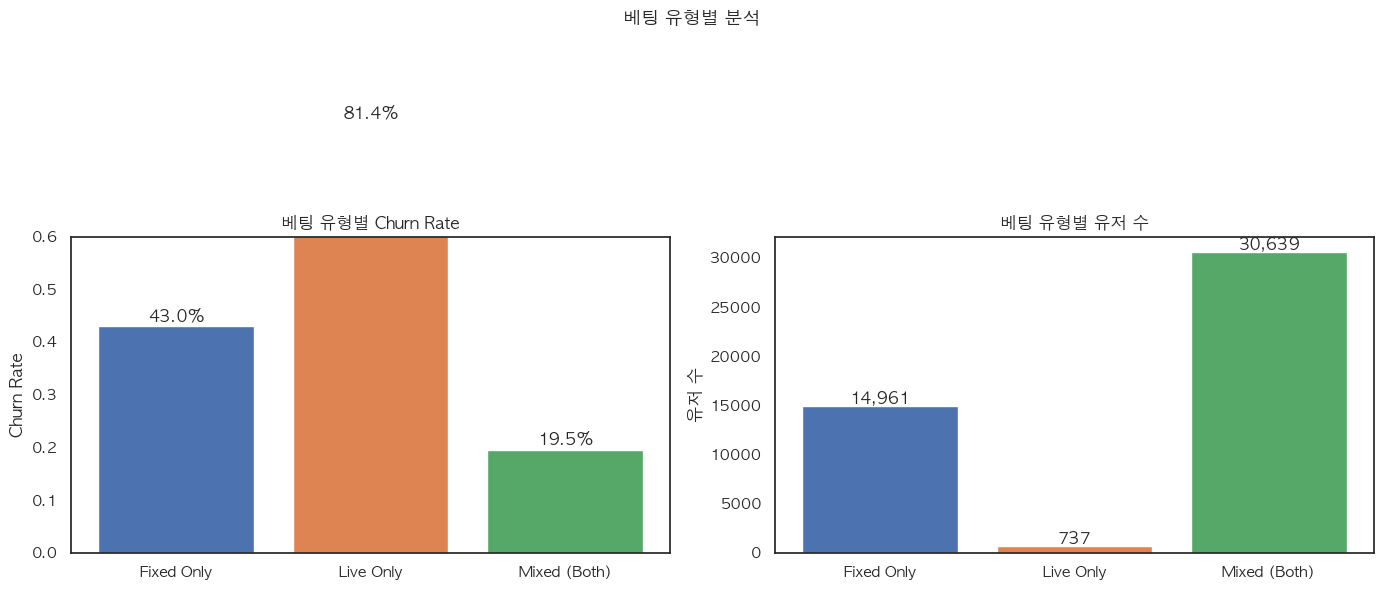

              count  churn_rate
bet_style                      
Fixed Only    14961    0.429784
Live Only       737    0.814111
Mixed (Both)  30639    0.195372


In [174]:
def get_bet_style(row):
    f, l = row['fixed_bet_amount'] > 0, row['live_bet_amount'] > 0
    if f and not l:   return 'Fixed Only'
    if l and not f:   return 'Live Only'
    if f and l:       return 'Mixed (Both)'
    return 'No Bet'

df_eda['bet_style'] = df_eda.apply(get_bet_style, axis=1)
order = ['Fixed Only', 'Live Only', 'Mixed (Both)']
palette = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('베팅 유형별 분석', fontsize=13)

s_churn = df_eda.groupby('bet_style')['churn'].mean().reindex(order)
bars = axes[0].bar(s_churn.index, s_churn.values, color=palette, edgecolor='white')
axes[0].set_title('베팅 유형별 Churn Rate', fontsize=12)
axes[0].set_ylabel('Churn Rate'); axes[0].set_ylim(0, 0.6)
for bar, v in zip(bars, s_churn.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.1%}', ha='center', fontweight='bold')

s_cnt = df_eda['bet_style'].value_counts().reindex(order)
bars2 = axes[1].bar(s_cnt.index, s_cnt.values, color=palette, edgecolor='white')
axes[1].set_title('베팅 유형별 유저 수', fontsize=12); axes[1].set_ylabel('유저 수')
for bar, v in zip(bars2, s_cnt.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+200, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

print(df_eda.groupby('bet_style')['churn'].agg(['count','mean']).reindex(order)
        .rename(columns={'mean':'churn_rate'}))

## 9. 승률·ROI 구간별 이탈률

`total_win_rate`와 `total_avg_roi`를 구간으로 나누어 각 구간의 이탈률 비교.


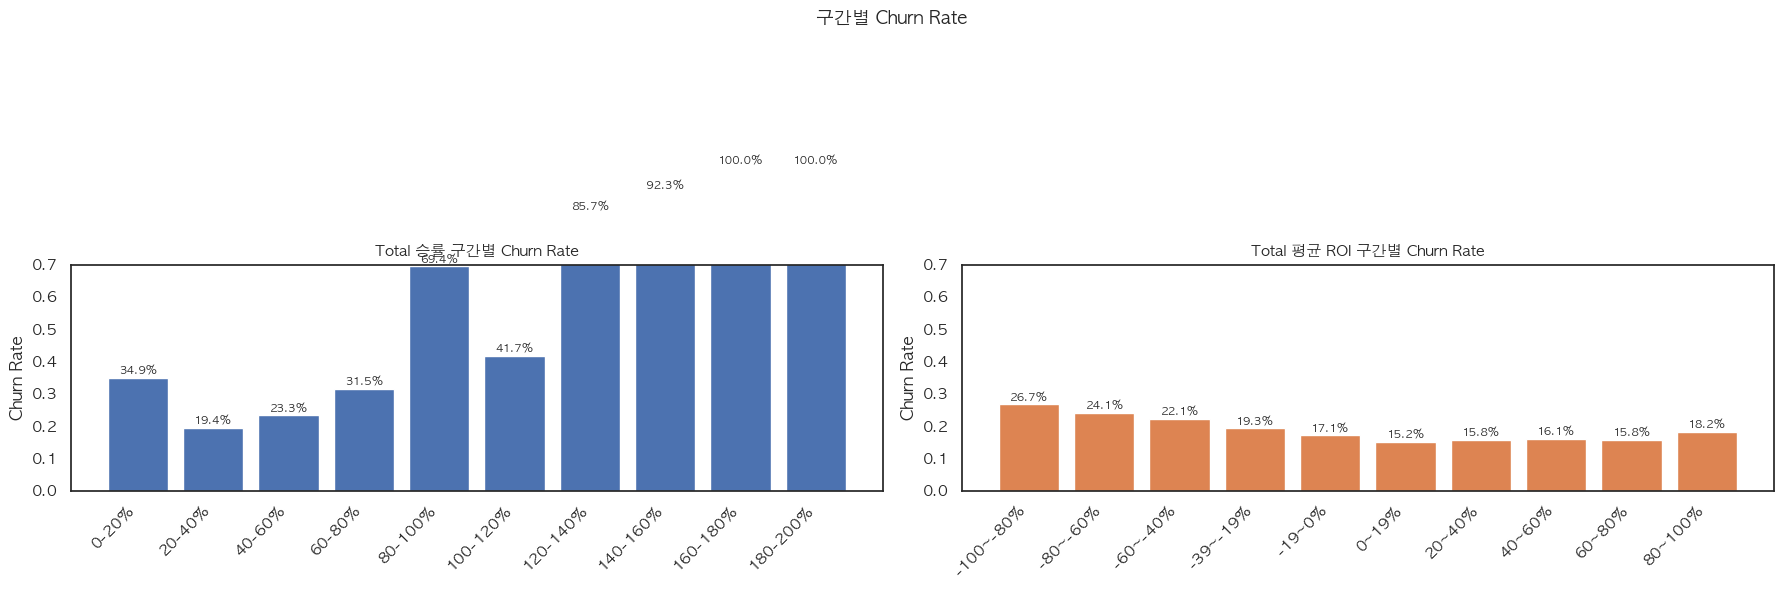

In [175]:
def churn_by_band(data, col, bins, labels):
    tmp = data.copy()
    tmp['_g'] = pd.cut(tmp[col], bins=bins, labels=labels, include_lowest=True)
    return tmp.groupby('_g', observed=True)['churn'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('구간별 Churn Rate', fontsize=13)

# 승률 (0~200%, PSY 방식)
win_bins   = [0.2*i for i in range(11)]
win_labels = [f'{i*20}-{(i+1)*20}%' for i in range(10)]
win_df = df_eda[df_eda['total_win_rate'] <= 2].copy()
wd = churn_by_band(win_df, 'total_win_rate', win_bins, win_labels)
bars = axes[0].bar(range(len(wd)), wd['churn'], color='#4C72B0', edgecolor='white')
axes[0].set_xticks(range(len(wd))); axes[0].set_xticklabels(wd['_g'], rotation=45, ha='right')
axes[0].set_title('Total 승률 구간별 Churn Rate', fontsize=11)
axes[0].set_ylabel('Churn Rate'); axes[0].set_ylim(0, 0.7)
for bar, v in zip(bars, wd['churn']):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.1%}', ha='center', fontsize=8)

# ROI (-100%~+100%)
rdf = df_eda[(df_eda['total_avg_roi']>=-1)&(df_eda['total_avg_roi']<=1)].copy()
roi_bins   = [-1.0+0.2*i for i in range(11)]
roi_labels = [f'{int((-1+0.2*i)*100)}~{int((-0.8+0.2*i)*100)}%' for i in range(10)]
rd = churn_by_band(rdf, 'total_avg_roi', roi_bins, roi_labels)
bars = axes[1].bar(range(len(rd)), rd['churn'], color='#DD8452', edgecolor='white')
axes[1].set_xticks(range(len(rd))); axes[1].set_xticklabels(rd['_g'], rotation=45, ha='right')
axes[1].set_title('Total 평균 ROI 구간별 Churn Rate', fontsize=11)
axes[1].set_ylabel('Churn Rate'); axes[1].set_ylim(0, 0.7)
for bar, v in zip(bars, rd['churn']):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.1%}', ha='center', fontsize=8)
plt.tight_layout(); plt.show()

## 10. 베팅 규모 구간별 유저 분포

베팅 금액·당첨 금액·베팅 건수를 구간별로 나눠 유저 수 분포 비교.


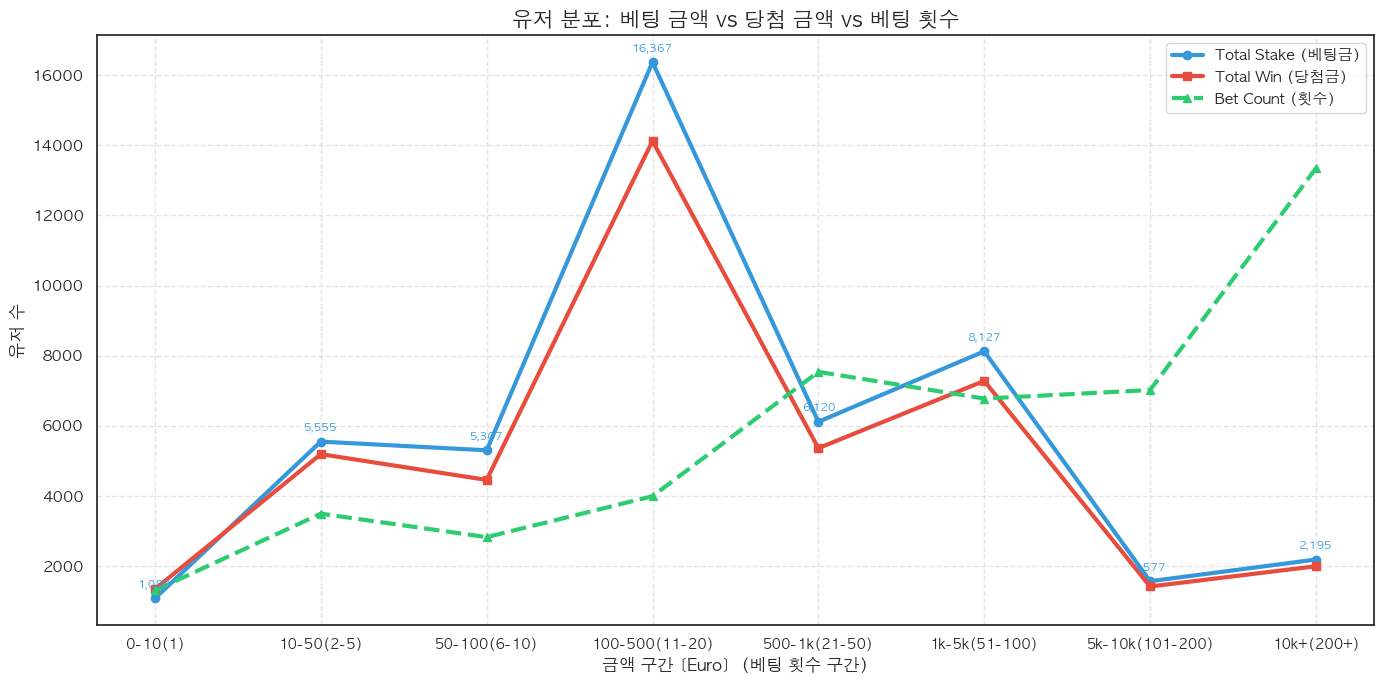

In [176]:
a_bins = [0,10,50,100,500,1000,5000,10000,np.inf]
a_lbl  = ['0-10','10-50','50-100','100-500','500-1k','1k-5k','5k-10k','10k+']
c_bins = [0,1,5,10,20,50,100,200,np.inf]
c_lbl  = ['1','2-5','6-10','11-20','21-50','51-100','101-200','200+']

stake_cnt = pd.cut(df['total_bet_amount'], bins=a_bins, labels=a_lbl).value_counts().sort_index()
win_cnt   = pd.cut(df['total_win_amount'],  bins=a_bins, labels=a_lbl).value_counts().sort_index()
bet_cnt   = pd.cut(df['total_bet_cnt'],     bins=c_bins, labels=c_lbl ).value_counts().sort_index()

df_plot = pd.DataFrame({'Rank':range(1,9),
    'Total Stake':stake_cnt.values,'Total Win':win_cnt.values,'Bet Count':bet_cnt.values})

plt.figure(figsize=(14, 7))
plt.plot(df_plot['Rank'], df_plot['Total Stake'], marker='o', label='Total Stake (베팅금)', lw=3, color='#3498db')
plt.plot(df_plot['Rank'], df_plot['Total Win'],   marker='s', label='Total Win (당첨금)',   lw=3, color='#e74c3c')
plt.plot(df_plot['Rank'], df_plot['Bet Count'],   marker='^', label='Bet Count (횟수)',     lw=3, ls='--', color='#2ecc71')
plt.xticks(df_plot['Rank'], [f'{a}({c})' for a,c in zip(a_lbl,c_lbl)], fontsize=10)
plt.title('유저 분포: 베팅 금액 vs 당첨 금액 vs 베팅 횟수', fontsize=15, fontweight='bold')
plt.ylabel('유저 수'); plt.xlabel('금액 구간 [Euro]  (베팅 횟수 구간)')
plt.legend(fontsize=11); plt.grid(True, ls='--', alpha=0.5)
for _, row in df_plot.iterrows():
    plt.text(row['Rank'], row['Total Stake']+300, f"{int(row['Total Stake']):,}",
             ha='center', color='#3498db', fontsize=8)
plt.tight_layout(); plt.show()

## 11. 첫 베팅 결과와 이탈률 ㄴㄴ

1회 베팅 유저의 **Win/Loss** 결과가 이탈에 영향을 주는지 분석.


1회 베팅 유저 : 1,313  (2.8%)
first_result
Loss    1221
Win       92


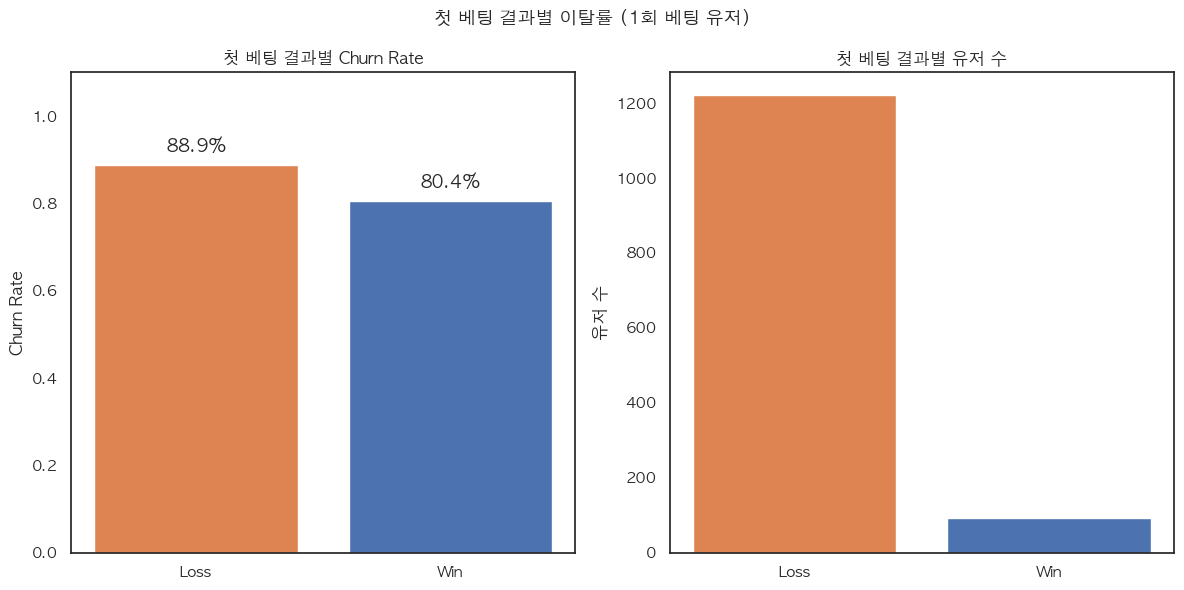


첫 베팅 결과별 Churn Rate:
first_result
Loss    0.888616
Win     0.804348


In [177]:
first_only = df[df['total_bet_cnt'] == 1].copy()
first_only['first_result'] = (first_only['total_win_amount'] > first_only['total_bet_amount']).map({True:'Win',False:'Loss'})

print(f'1회 베팅 유저 : {len(first_only):,}  ({len(first_only)/len(df)*100:.1f}%)')
print(first_only['first_result'].value_counts().to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('첫 베팅 결과별 이탈률 (1회 베팅 유저)', fontsize=13)

cr = first_only.groupby('first_result')['churn'].mean().reindex(['Loss','Win'])
bars = axes[0].bar(cr.index, cr.values, color=['#DD8452','#4C72B0'], edgecolor='white')
axes[0].set_title('첫 베팅 결과별 Churn Rate', fontsize=12)
axes[0].set_ylabel('Churn Rate'); axes[0].set_ylim(0, 1.1)
for bar, v in zip(bars, cr.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.03,
                 f'{v:.1%}', ha='center', fontsize=13, fontweight='bold')

cnt = first_only['first_result'].value_counts().reindex(['Loss','Win'])
axes[1].bar(cnt.index, cnt.values, color=['#DD8452','#4C72B0'], edgecolor='white')
axes[1].set_title('첫 베팅 결과별 유저 수', fontsize=12); axes[1].set_ylabel('유저 수')
plt.tight_layout(); plt.show()
print('\n첫 베팅 결과별 Churn Rate:'); print(cr.to_string())

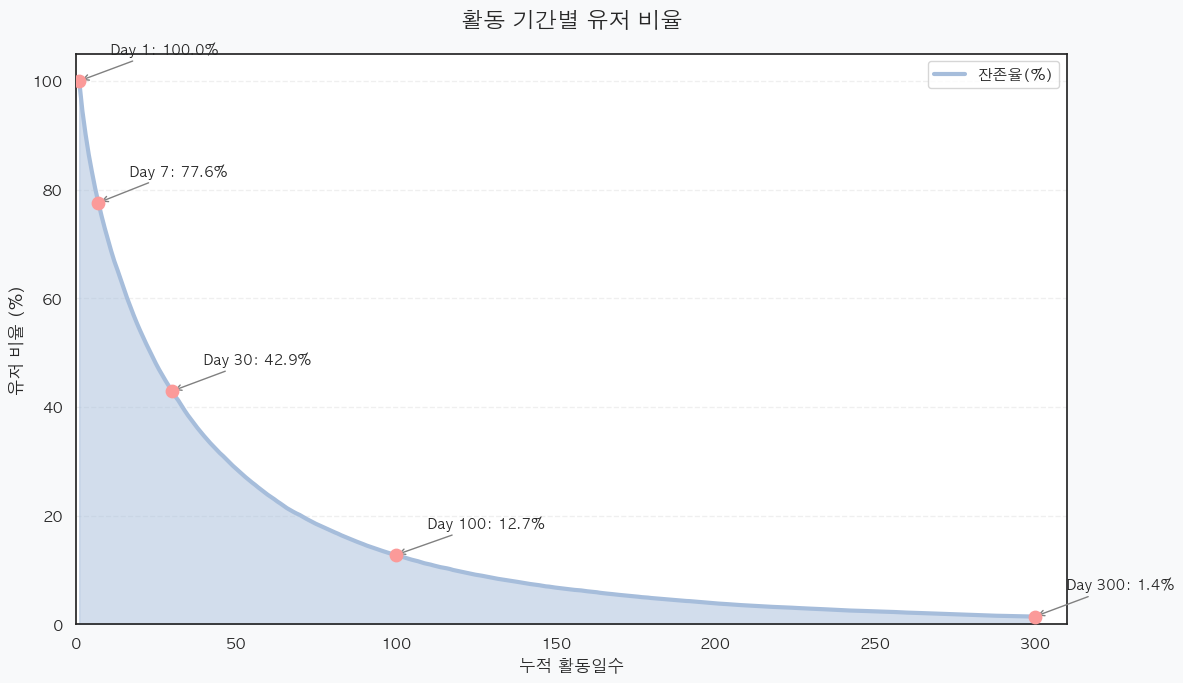

In [178]:
# 활동 기간 별 유저 비율
# 1. 스타일 및 폰트 설정
plt.figure(figsize=(12, 7), facecolor='#f8f9fa')

# 2. total_active_days 데이터 추출 및 300일 제한 리텐션 계산
total_users = len(df)
retention_data = []

# 최대 범위를 300으로 제한
target_range = min(300, int(df['total_active_days'].max()))

for i in range(1, target_range + 1):
    remaining_users = len(df[df['total_active_days'] >= i])
    retention_rate = (remaining_users / total_users) * 100
    retention_data.append({'Day': i, 'Retention_Rate': retention_rate})

df_retention_300 = pd.DataFrame(retention_data)

# 3. 시각화 (연한 파스텔톤 반영)
plt.plot(df_retention_300['Day'], df_retention_300['Retention_Rate'], 
         color='#a6bddb', linewidth=3, label='잔존율(%)')
plt.fill_between(df_retention_300['Day'], df_retention_300['Retention_Rate'], 
                 color='#a6bddb', alpha=0.5)

# 4. 주요 변곡점 주석 (Day 1, 7, 30, 100, 300 등)
check_points = [1, 7, 30, 100, 300]
for day in check_points:
    if day <= target_range:
        rate = df_retention_300.loc[df_retention_300['Day'] == day, 'Retention_Rate'].values[0]
        plt.scatter(day, rate, color='#fb9a99', s=80, zorder=5)
        plt.annotate(f'Day {day}: {rate:.1f}%', 
                     xy=(day, rate), xytext=(day+10, rate+5),
                     arrowprops=dict(arrowstyle='->', color='gray'),
                     fontsize=10, fontweight='bold')

# 5. 그래프 세부 설정
plt.title('활동 기간별 유저 비율', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('누적 활동일수', fontsize=12)
plt.ylabel('유저 비율 (%)', fontsize=12)
plt.xlim(0, 310) 
plt.ylim(0, 105)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

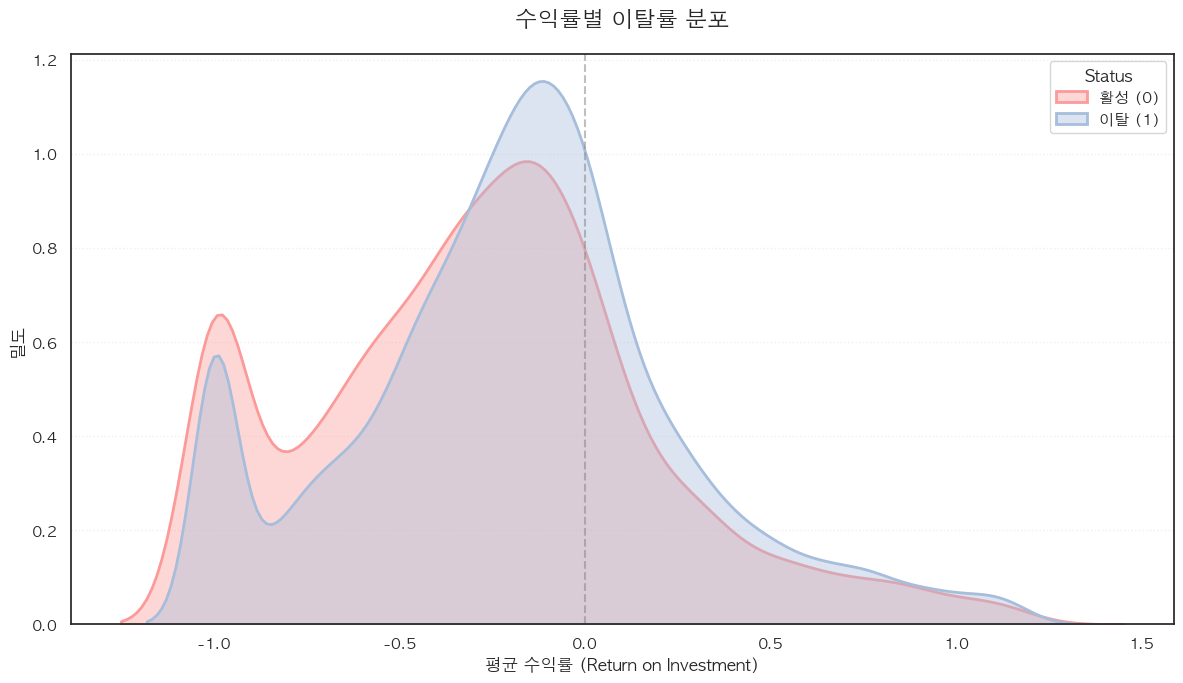

In [179]:
# 수익률별 이탈율 분포

# 1. ROI 분포 시각화 (이상치 제외: -1.2 ~ 1.2 구간 집중)
plt.figure(figsize=(12, 7))

# 연한 파스텔 톤 설정 (Light Blue: 활성, Light Red: 이탈)
palette = {0: "#a6bddb", 1: "#fb9a99"} 

# KDE Plot (커널 밀도 추정 그래프)로 분포 비교
sns.kdeplot(data=df_eda[(df_eda['total_avg_roi'] >= -1.2) & (df_eda['total_avg_roi'] <= 1.2)], 
            x='total_avg_roi', 
            hue='churn', 
            fill=True, 
            common_norm=False, 
            palette=palette, 
            alpha=0.4,
            linewidth=2)

# 기준선 표시 (ROI 0: 본전)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5, label='Break-even')

plt.title('수익률별 이탈률 분포', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('평균 수익률 (Return on Investment)', fontsize=12)
plt.ylabel('밀도', fontsize=12)

# 범례 이름 변경
plt.legend(title='Status', labels=['활성 (0)', '이탈 (1)'])

plt.grid(axis='y', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

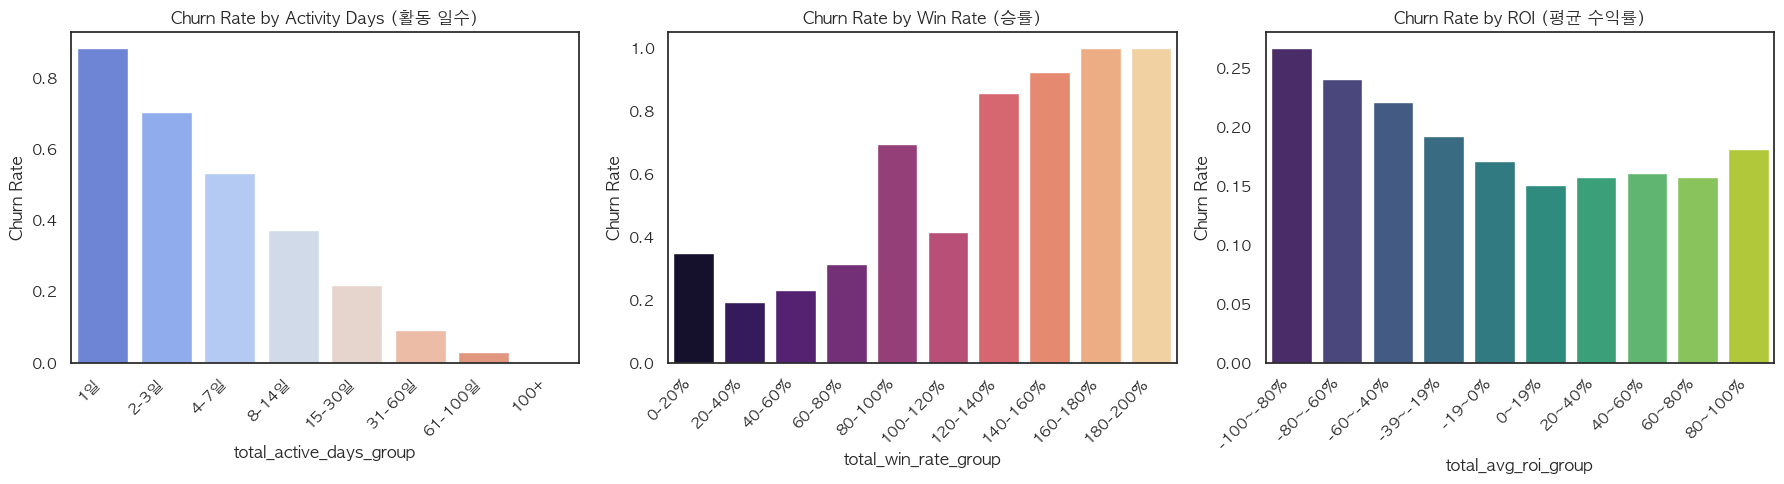

In [180]:
# 구간별 Churn Rate 분석 (3개 그래프)
def get_labeled_churn_rate(df, column, bins, labels):
    df_copy = df.copy()
    df_copy[f'{column}_group'] = pd.cut(df_copy[column], bins=bins, labels=labels, include_lowest=True)
    group_churn = df_copy.groupby(f'{column}_group', observed=True)['churn'].mean().reset_index()
    return group_churn

plt.figure(figsize=(18, 5))

# --- (1) Total Active Days (활동 일수) ---
plt.subplot(1, 3, 1)
days_bins = [0, 1, 3, 7, 14, 30, 60, 100, 365]
days_labels = ['1일', '2-3일', '4-7일', '8-14일', '15-30일', '31-60일', '61-100일', '100+']
temp_days_df = df_eda[df_eda['total_active_days'] > 0].copy()
days_churn_data = get_labeled_churn_rate(temp_days_df, 'total_active_days', days_bins, days_labels)
sns.barplot(x='total_active_days_group', y='churn', data=days_churn_data, palette='coolwarm')
plt.title('Churn Rate by Activity Days (활동 일수)', fontsize=12)
plt.ylabel('Churn Rate')
plt.xticks(rotation=45, ha='right')

# --- (2) Total Win Rate (승리확률, PSY 방식 0~200%) ---
plt.subplot(1, 3, 2)
win_bins = [0.2 * i for i in range(11)]
win_labels = [f'{i*20}-{(i+1)*20}%' for i in range(10)]
temp_win_df = df_eda[df_eda['total_win_rate'] <= 2].copy()
win_churn_data = get_labeled_churn_rate(temp_win_df, 'total_win_rate', win_bins, win_labels)
sns.barplot(x='total_win_rate_group', y='churn', data=win_churn_data, palette='magma')
plt.title('Churn Rate by Win Rate (승률)', fontsize=12)
plt.ylabel('Churn Rate')
plt.xticks(rotation=45, ha='right')

# --- (3) Total Avg ROI (평균 ROI) ---
plt.subplot(1, 3, 3)
roi_bins = [-1.0 + 0.2 * i for i in range(11)]
roi_labels = [f'{int((-1.0 + 0.2 * i)*100)}~{int((-0.8 + 0.2 * i)*100)}%' for i in range(10)]
temp_roi_df = df_eda[(df_eda['total_avg_roi'] >= -1) & (df_eda['total_avg_roi'] <= 1) & (df_eda['total_avg_roi'].notna())].copy()
roi_churn_data = get_labeled_churn_rate(temp_roi_df, 'total_avg_roi', roi_bins, roi_labels)
sns.barplot(x='total_avg_roi_group', y='churn', data=roi_churn_data, palette='viridis')
plt.title('Churn Rate by ROI (평균 수익률)', fontsize=12)
plt.ylabel('Churn Rate')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()